1. Из ноутбуков по практике "Рекуррентные и одномерные сверточные нейронные сети" выберите лучшую сеть, либо создайте свою.
2. Запустите раздел "Подготовка"
3. Подготовьте датасет с параметрами `VOCAB_SIZE=20'000`, `WIN_SIZE=1000`, `WIN_HOP=100`, как в ноутбуке занятия, и обучите выбранную сеть. Параметры обучения можно взять из практического занятия. Для  всех обучаемых сетей в данной работе они должны быть одни и теже.
4. Поменяйте размер словаря tokenaizera (`VOCAB_SIZE`) на `5000`, `10000`, `40000`.  Пересоздайте датасеты, при этом оставьте `WIN_SIZE=1000`, `WIN_HOP=100`.
Обучите выбранную нейронку на этих датасетах.  Сделайте выводы об  изменении  точности распознавания авторов текстов. Результаты сведите в таблицу
5. Поменяйте длину отрезка текста и шаг окна разбиения текста на векторы  (`WIN_SIZE`, `WIN_HOP`) используя значения (`500`,`50`) и (`2000`,`200`). Пересоздайте датасеты, при этом оставьте `VOCAB_SIZE=20000`. Обучите выбранную нейронку на этих датасетах. Сделайте выводы об  изменении точности распознавания авторов текстов.

Результаты всей работы сведите в таблицу.

## Подготовка

In [1]:
# Работа с массивами данных
import numpy as np


# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Input

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Рисование схемы модели
from tensorflow.keras.utils import plot_model

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Вывод объектов в ячейке colab
from IPython.display import display

from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline

In [2]:
# Загрузим датасет из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [3]:
# Распакуем архив в папку writers
!unzip -o writers.zip -d writers/


Archive:  writers.zip
  inflating: writers/(Клиффорд_Саймак) Обучающая_5 вместе.txt  
  inflating: writers/(Клиффорд_Саймак) Тестовая_2 вместе.txt  
  inflating: writers/(Макс Фрай) Обучающая_5 вместе.txt  
  inflating: writers/(Макс Фрай) Тестовая_2 вместе.txt  
  inflating: writers/(О. Генри) Обучающая_50 вместе.txt  
  inflating: writers/(О. Генри) Тестовая_20 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Обучающая_22 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Тестовая_8 вместе.txt  
  inflating: writers/(Стругацкие) Обучающая_5 вместе.txt  
  inflating: writers/(Стругацкие) Тестовая_2 вместе.txt  
  inflating: writers/(Булгаков) Обучающая_5 вместе.txt  
  inflating: writers/(Булгаков) Тестовая_2 вместе.txt  


In [4]:
# Настройка констант для загрузки данных
FILE_DIR  = 'writers'                     # Папка с текстовыми файлами
SIG_TRAIN = 'обучающая'                   # Признак обучающей выборки в имени файла
SIG_TEST  = 'тестовая'                    # Признак тестовой выборки в имени файла

In [5]:
# Подготовим пустые списки

CLASS_LIST = []
text_train = []
text_test = []

file_list = sorted(os.listdir(FILE_DIR))

for file_name in file_list:
    m = re.match(r'^\((.+?)\)\s+(.+?)(?:_|$)', file_name)
    if not m:
        continue

    class_name = m.group(1)
    subset_name = m.group(2).lower()

    is_train = SIG_TRAIN in subset_name
    is_test = SIG_TEST in subset_name

    if not (is_train or is_test):
        continue

    if class_name not in CLASS_LIST:
        print(f'Добавление класса "{class_name}"')
        CLASS_LIST.append(class_name)
        text_train.append('')
        text_test.append('')

    cls = CLASS_LIST.index(class_name)
    print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка.')

    file_path = os.path.join(FILE_DIR, file_name)
    with open(file_path, 'r', encoding='utf-8-sig') as f:
        text = f.read()

    subset = text_train if is_train else text_test
    subset[cls] += ' ' + text.replace('\n', ' ').strip()


Добавление класса "Булгаков"
Добавление файла "(Булгаков) Обучающая_5 вместе.txt" в класс "Булгаков", обучающая выборка.
Добавление файла "(Булгаков) Тестовая_2 вместе.txt" в класс "Булгаков", тестовая выборка.
Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Обучающая_5 вместе.txt" в класс "Клиффорд_Саймак", обучающая выборка.
Добавление файла "(Клиффорд_Саймак) Тестовая_2 вместе.txt" в класс "Клиффорд_Саймак", тестовая выборка.
Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Обучающая_5 вместе.txt" в класс "Макс Фрай", обучающая выборка.
Добавление файла "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай", тестовая выборка.
Добавление класса "О. Генри"
Добавление файла "(О. Генри) Обучающая_50 вместе.txt" в класс "О. Генри", обучающая выборка.
Добавление файла "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри", тестовая выборка.
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберр

In [6]:
# Определим количество классов
CLASS_COUNT = len(CLASS_LIST)
print(f'Всего классов: {CLASS_COUNT}')

Всего классов: 6


In [7]:
# Выведем прочитанные классы текстов
print(CLASS_LIST)

['Булгаков', 'Клиффорд_Саймак', 'Макс Фрай', 'О. Генри', 'Рэй Брэдберри', 'Стругацкие']


In [8]:
# Посчитаем количество текстов в обучающей выборке
print(len(text_train))

6


In [9]:
# Проверим загрузки: выведем начальные отрывки из каждого класса

for cls in range(CLASS_COUNT):                   # Запустим цикл по числу классов
    print(f'Класс: {CLASS_LIST[cls]}')           # Выведем имя класса
    print(f'  train: {text_train[cls][:200]}')   # Выведем фрагмент обучающей выборки
    print(f'  test : {text_test[cls][:200]}')    # Выведем фрагмент тестовой выборки
    print()

Класс: Булгаков
  train:  Белая гвардия   Посвящается[1]  Любови Евгеньевне Белозерской[2]  Пошел мелкий снег и вдруг повалил хло-  пьями. Ветер завыл; сделалась метель.  В одно мгновение темное небо смешалось с  снежным море
  test :  Дон Кихот ДЕЙСТВУЮЩИЕ ЛИЦА Алонсо Кихано, он же Дон Кихот Ламанчский.  Антония – его племянница.  Ключница Дон Кихота.  Санчо Панса – оруженосец Дон Кихота.  Перо Перес – деревенский священник, лицен

Класс: Клиффорд_Саймак
  train:  Всё живое...     Когда я выехал из нашего городишка и повернул на шоссе, позади оказался грузовик. Этакая тяжелая громадина с прицепом, и неслась она во весь дух. Шоссе здесь срезает угол городка, и 
  test :  Зачарованное паломничество    1  Гоблин со стропил следил за прячущимся монахом, который шпионил за ученым. Гоблин ненавидел монаха и имел для этого все основания. Монах никого не ненавидел и не люби

Класс: Макс Фрай
  train:  Власть несбывшегося   – С тех пор как меня угораздило побывать в этой грешной Черхавле, мне 

## Решение

## Настройка гиперпараметров 

In [29]:
# Задание параметров преобразования
VOCAB_SIZE = 20000                        # Объем словаря для токенизатора
WIN_SIZE   = 500                        # Длина отрезка текста (окна) в словах
WIN_HOP    = 20                         # Шаг окна разбиения текста на векторы
EPOCHS     = 50                           # Количество эпох обучения модели
BATCH_SIZE = 128                          # Размер батча для обучения модели

## Преобразование текстов в последовательности 

In [30]:
t = Tokenizer(num_words=VOCAB_SIZE)           # Создадим токенизатор для преобразования текстов в последовательности
t.fit_on_texts(text_train)                   # Построим словарь токенизатора на обучающей выборке
items = list(t.word_index.items())
print(f'Всего слов в словаре: {len(items)}')  # Выведем количество слов в словаре токенизатора
print(f'Первые 20 слов в словаре: {items[:20]}')  # Выведем первые 20 слов в словаре токенизатора

Всего слов в словаре: 146934
Первые 20 слов в словаре: [('и', 1), ('–', 2), ('в', 3), ('не', 4), ('я', 5), ('что', 6), ('на', 7), ('—', 8), ('с', 9), ('он', 10), ('а', 11), ('как', 12), ('то', 13), ('это', 14), ('но', 15), ('все', 16), ('у', 17), ('по', 18), ('его', 19), ('к', 20)]


## Преобразуйте выборки обученным токенайзером в последовательность индексов:

In [31]:
seq_train = t.texts_to_sequences(text_train)
seq_test = t.texts_to_sequences(text_test)

print("Фрагмент обучающего текста:")
print("В виде оригинального текста:              ", text_train[1][:101])
print("Он же в виде последовательности индексов: ", seq_train[1][:20])

Фрагмент обучающего текста:
В виде оригинального текста:                Всё живое...     Когда я выехал из нашего городишка и повернул на шоссе, позади оказался грузовик. Э
Он же в виде последовательности индексов:  [146, 2937, 42, 5, 11729, 23, 509, 1, 1802, 7, 934, 962, 591, 2189, 12021, 4574, 9, 1, 7489, 39]


## Статистика по текстам

In [32]:
# Функция вывода статистики по текстам
def print_text_stats(title, texts, sequences, class_labels=CLASS_LIST):
    # Суммарное количество символов и слов в тексте
    chars = 0
    words = 0

    print(f'Статистика по {title} текстам:')

    # Вывод итогов по всем классам данного набора текстов и их последовательностей индексов
    for cls in range(len(class_labels)):
        print('{:<15} {:9} символов,{:8} слов'.format(class_labels[cls],
                                                      len(texts[cls]),
                                                      len(sequences[cls])))
        chars += len(texts[cls])
        words += len(sequences[cls])

    print('----')
    print('{:<15} {:9} символов,{:8} слов\n'.format('В сумме', chars, words))

# Вывод итогов по текстам
print_text_stats('обучающим', text_train, seq_train)
print_text_stats('тестовым', text_test, seq_test)

Статистика по обучающим текстам:
Булгаков          1765647 символов,  222966 слов
Клиффорд_Саймак   1609507 символов,  228982 слов
Макс Фрай         3700010 символов,  529816 слов
О. Генри          1049518 символов,  133912 слов
Рэй Брэдберри     1386454 символов,  187195 слов
Стругацкие        2042465 символов,  280673 слов
----
В сумме          11553601 символов, 1583544 слов

Статистика по тестовым текстам:
Булгаков           875042 символов,  111363 слов
Клиффорд_Саймак    318811 символов,   44157 слов
Макс Фрай         1278191 символов,  173054 слов
О. Генри           349662 символов,   42821 слов
Рэй Брэдберри      868673 символов,  109553 слов
Стругацкие         704846 символов,   91852 слов
----
В сумме           4395225 символов,  572800 слов



## Формирование обучающей и тестовой выборок в виде массивов отрезков текста и классов

In [33]:
# Функция разбиения последовательности на отрезки скользящим окном
# На входе - последовательность индексов, размер окна, шаг окна
def split_sequence(sequence, win_size, hop):
    # Последовательность разбивается на части до последнего полного окна
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]


# Функция формирования выборок из последовательностей индексов
# формирует выборку отрезков и соответствующих им меток классов в виде one hot encoding
def vectorize_sequence(seq_list, win_size, hop):
    # В списке последовательности следуют в порядке их классов
    # Всего последовательностей в списке ровно столько, сколько классов
    class_count = len(seq_list)

    # Списки для исходных векторов и категориальных меток класса
    x, y = [], []

    # Для каждого класса:
    for cls in range(class_count):
        # Разбиение последовательности класса cls на отрезки
        vectors = split_sequence(seq_list[cls], win_size, hop)
        # Добавление отрезков в выборку
        x += vectors
        # Для всех отрезков класса cls добавление меток класса в виде OHE
        y += [cls] * len(vectors)

    # Возврат результатов как numpy-массивов
    return np.array(x), np.array(y)

In [34]:
x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
    # Формирование тестовой выборки
x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)

    # Проверка формы сформированных данных
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
print(x_train[0])

(79030, 500) (79030,)
(28493, 500) (28493,)
[ 3730  8278  1525 15522  1572   358  8694  1271     1   125 14311   702
 11513 10176 17052     3   278  1058  4699   634     9  6976    16  2820
     8    54     8  1173     8  1690  1620     1    97  3427   940    18
     3  5547 18908     9  3891   531  6203    44   491     1  8695   491
    18  3025    33   513    27  4700   560  2397    44    10  2865  3497
    11  4701     1   594  1947     3  1222   794   392  1876  5161     8
     1  2434 18909  4331  3026    15   853     1     3     1     3 14312
   945 15523    12  8696     1  3428  3731     4  4098    12     3 10837
   973  7246    41  1355   327  9111  4701     1 17053  1261 12279  4449
    72    27    26  3138   106   491   131    99    12  2287  1050  3578
     9 15524  3805     1     3   569  1210    42  1312  1075  4450  3806
   756  3807   131  3732     1  7912   451     7 11514     3   276  4099
     3 11515   973  6977     9  2866  1541    18 18910     7  8279     3
  2507 

In [25]:
# Функция компиляции и обучения модели нейронной сети
def compile_train_model(model,
                        x_train,
                        y_train,
                        x_val,
                        y_val,
                        optimizer='adam',
                        epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        figsize=(20, 5)):

    # Компиляция модели
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Вывод сводки
    model.summary()

    # Вывод схемы модели
    display(plot_model(model, dpi=60, show_shapes=True))

    early_stopping = EarlyStopping(
                    monitor='val_loss', 
                    patience=5, 
                    restore_best_weights=True)

    # Обучение модели с заданными параметрами
    history = model.fit(x_train,
                        y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_val, y_val),
                        callbacks=[early_stopping])

    # Вывод графиков точности и ошибки
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'],
               label='Доля верных ответов на обучающем наборе')
    ax1.plot(history.history['val_accuracy'],
               label='Доля верных ответов на проверочном наборе')
    ax1.xaxis.get_major_locator().set_params(integer=True)
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('Доля верных ответов')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающем наборе')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочном наборе')
    ax2.xaxis.get_major_locator().set_params(integer=True)
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()


# Функция вывода результатов оценки модели на заданных данных
def eval_model(model, x, y_true, class_labels=[], title='', figsize=(10, 10)):

    y_pred = model.predict(x)

    y_pred_cls = np.argmax(y_pred, axis=1) 
    y_true_cls = y_true  
    acc = (y_pred_cls == y_true_cls).mean()

    
    cm = confusion_matrix(y_true_cls, y_pred_cls, normalize='true')

    cm_rounded = np.around(cm, 3)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f'Confusion Matrix: {title}', fontsize=16)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_rounded,
        display_labels=class_labels
    )

    disp.plot(ax=ax, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print('-' * 80)
    print(f'Accuracy: {acc:.4f}')

    # правильная интерпретация
    for i in range(len(class_labels)):
        predicted_class = np.argmax(cm[i])
        status = "OK" if predicted_class == i else "ERROR"

        print(f"{class_labels[i]:<20} → {class_labels[predicted_class]:<20} | {status}")

    print(f"\nMean class accuracy: {np.mean(np.diag(cm)):.4f}")


# Совместная функция обучения и оценки модели нейронной сети
def compile_train_eval_model(model,
                             x_train,
                             y_train,
                             x_test,
                             y_test,
                             class_labels=CLASS_LIST,
                             title='',
                             optimizer='adam',
                             epochs=EPOCHS,
                             batch_size=BATCH_SIZE,
                             graph_size=(20, 5),
                             cm_size=(10, 10)):

    # Компиляция и обучение модели на заданных параметрах
    # В качестве проверочных используются тестовые данные
    compile_train_model(model,
                        x_train, y_train,
                        x_test, y_test,
                        optimizer=optimizer,
                        epochs=epochs,
                        batch_size=batch_size,
                        figsize=graph_size)

    # Вывод результатов оценки работы модели на тестовых данных
    eval_model(model, x_test, y_test,
               class_labels=class_labels,
               title=title,
               figsize=cm_size)

## Создание и обучение нейронной сети

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 500, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 500, 50)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 500, 50)        │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 500, 16)        │         3,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 500, 16)        │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 500, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 500, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 500, 16)        │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 16)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 200)            │         3,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         1,206 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,374 (3.87 MB)

 Trainable params: 1,013,810 (3.87 MB)

 Non-trainable params: 564 (2.20 KB)

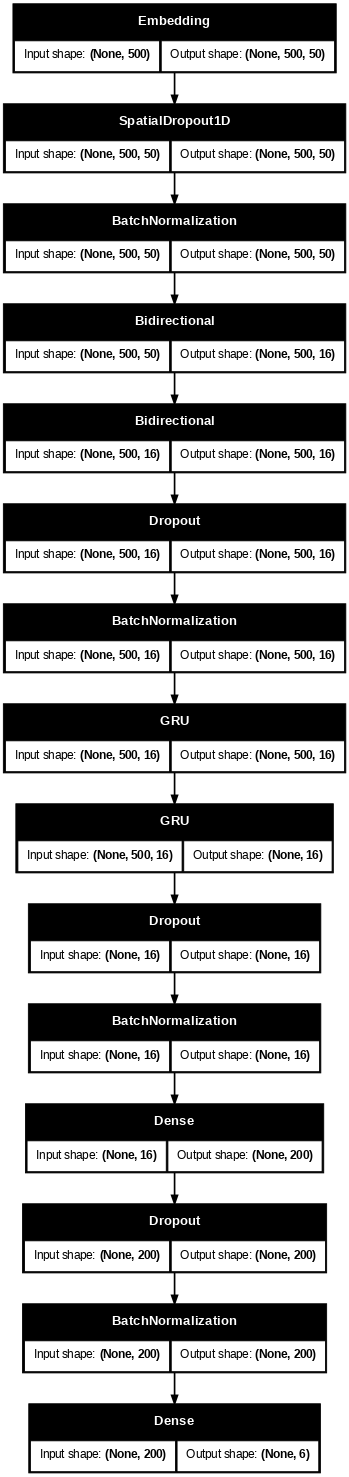

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - accuracy: 0.2441 - loss: 2.0198 - val_accuracy: 0.3026 - val_loss: 1.7276
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.3674 - loss: 1.6433 - val_accuracy: 0.3026 - val_loss: 1.6657
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.5070 - loss: 1.2713 - val_accuracy: 0.2293 - val_loss: 1.7462
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.6148 - loss: 1.0055 - val_accuracy: 0.4348 - val_loss: 1.5897
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.7019 - loss: 0.8022 - val_accuracy: 0.4691 - val_loss: 1.4480
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.7822 - loss: 0.6022 - val_accuracy: 0.4898 - val_loss: 2.3956
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.8477 - loss: 0.4309 - val_accuracy: 0.5266 - val_loss: 2.5696
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.9025 - loss: 0.3000 - val_accuracy: 0

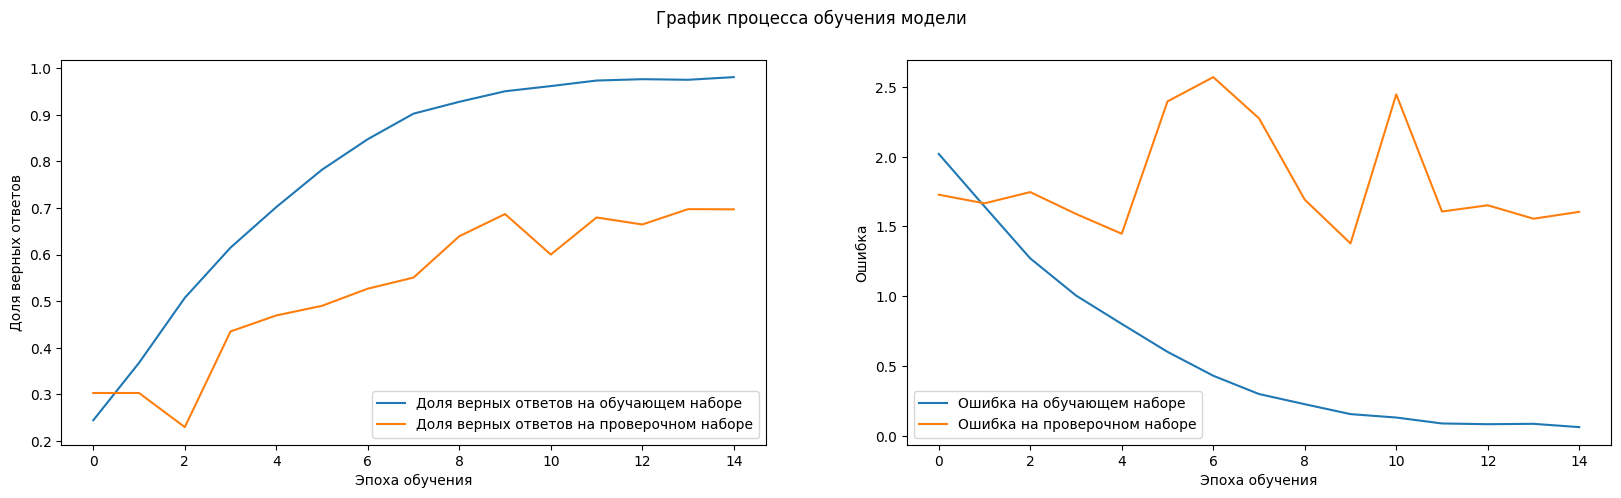

90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step


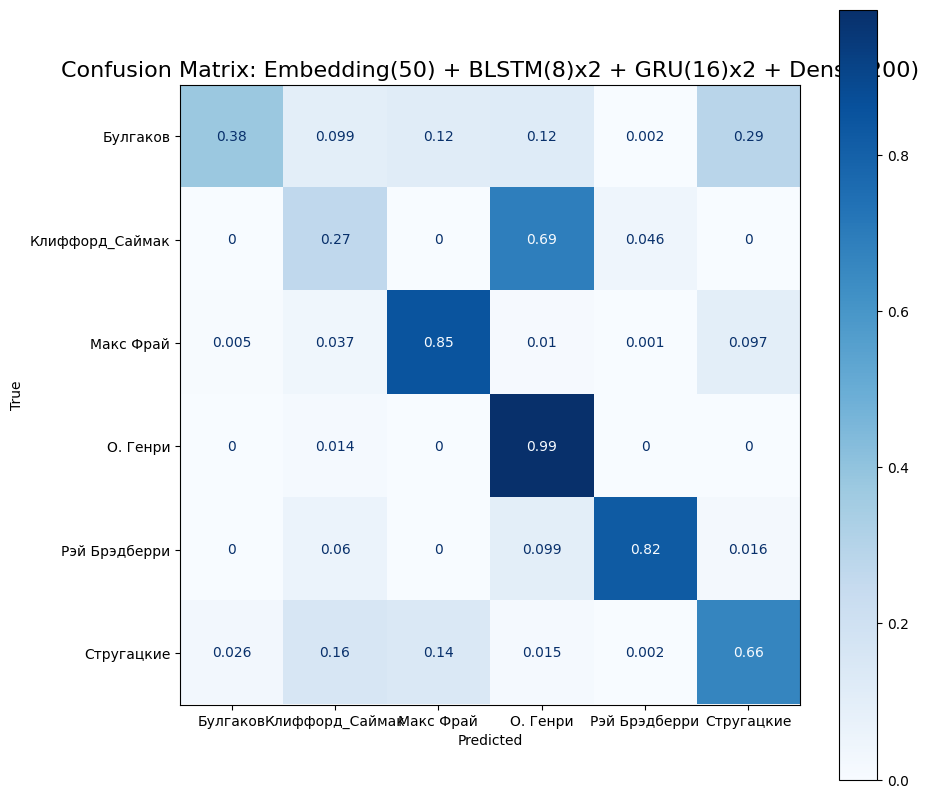

--------------------------------------------------------------------------------
Accuracy: 0.6869
Булгаков             → Булгаков             | OK
Клиффорд_Саймак      → О. Генри             | ERROR
Макс Фрай            → Макс Фрай            | OK
О. Генри             → О. Генри             | OK
Рэй Брэдберри        → Рэй Брэдберри        | OK
Стругацкие           → Стругацкие           | OK

Mean class accuracy: 0.6596


In [27]:
model_LSTM = Sequential([
    Input(shape=(WIN_SIZE,)),   
    Embedding(VOCAB_SIZE, 50),
    SpatialDropout1D(0.4),
    BatchNormalization(),

    Bidirectional(LSTM(8, return_sequences=True)),
    Bidirectional(LSTM(8, return_sequences=True)),
    Dropout(0.3),
    BatchNormalization(),

    GRU(16, return_sequences=True, reset_after=True),
    GRU(16, reset_after=True),
    Dropout(0.3),
    BatchNormalization(),

    Dense(200, activation='relu'),
    Dropout(0.3),
    BatchNormalization(),
    Dense(CLASS_COUNT, activation='softmax')
]
)




compile_train_eval_model(model_LSTM,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=EPOCHS,
                         batch_size=BATCH_SIZE,
                         class_labels=CLASS_LIST,
                         title='Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200)')

In [44]:
model_LSTM.save('model_LSTM_v_1.keras')

## Поменял размер словаря tokenaizera (`VOCAB_SIZE`) на  `40000`,  при этом оставил `WIN_SIZE=1000`, `WIN_HOP=100`. 

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 1000, 50)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 1000, 50)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1000, 50)       │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 1000, 16)       │         3,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 1000, 16)       │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1000, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1000, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 1000, 16)       │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 16)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │         3,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,206 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,014,374 (7.68 MB)

 Trainable params: 2,013,810 (7.68 MB)

 Non-trainable params: 564 (2.20 KB)

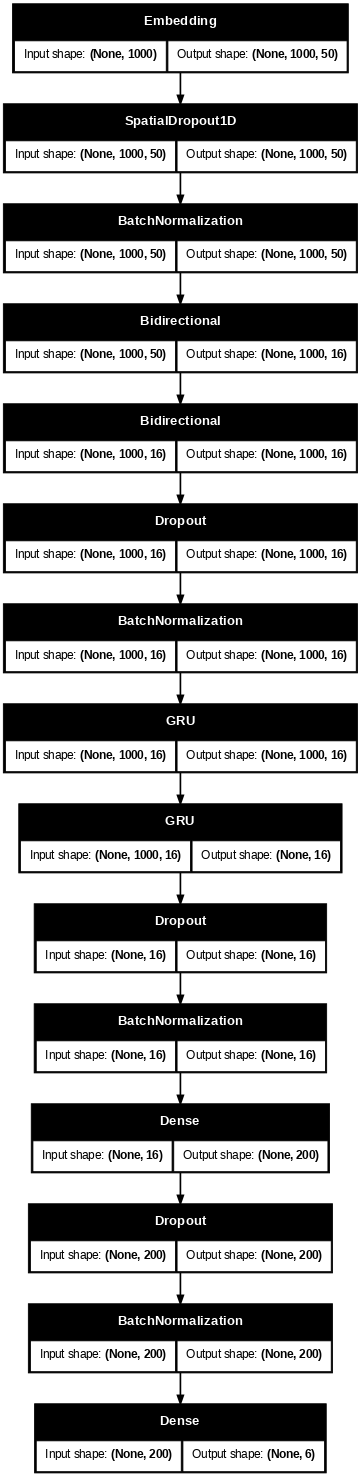

Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 39s 213ms/step - accuracy: 0.2643 - loss: 1.9432 - val_accuracy: 0.3015 - val_loss: 1.7294
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 27s 202ms/step - accuracy: 0.4982 - loss: 1.3086 - val_accuracy: 0.1635 - val_loss: 1.9606
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 27s 205ms/step - accuracy: 0.6877 - loss: 0.8409 - val_accuracy: 0.1904 - val_loss: 2.6794
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 27s 205ms/step - accuracy: 0.7459 - loss: 0.6997 - val_accuracy: 0.5040 - val_loss: 1.8870
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 27s 207ms/step - accuracy: 0.8826 - loss: 0.3499 - val_accuracy: 0.5983 - val_loss: 1.4539
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 27s 205ms/step - accuracy: 0.9242 - loss: 0.2370 - val_accuracy: 0.5578 - val_loss: 1.8823
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 27s 204ms/step - accuracy: 0.9436 - loss: 0.1820 - val_accuracy: 0.6736 - val_loss: 0.9829
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 27s 205ms/step - accuracy: 0.9740 - loss: 0

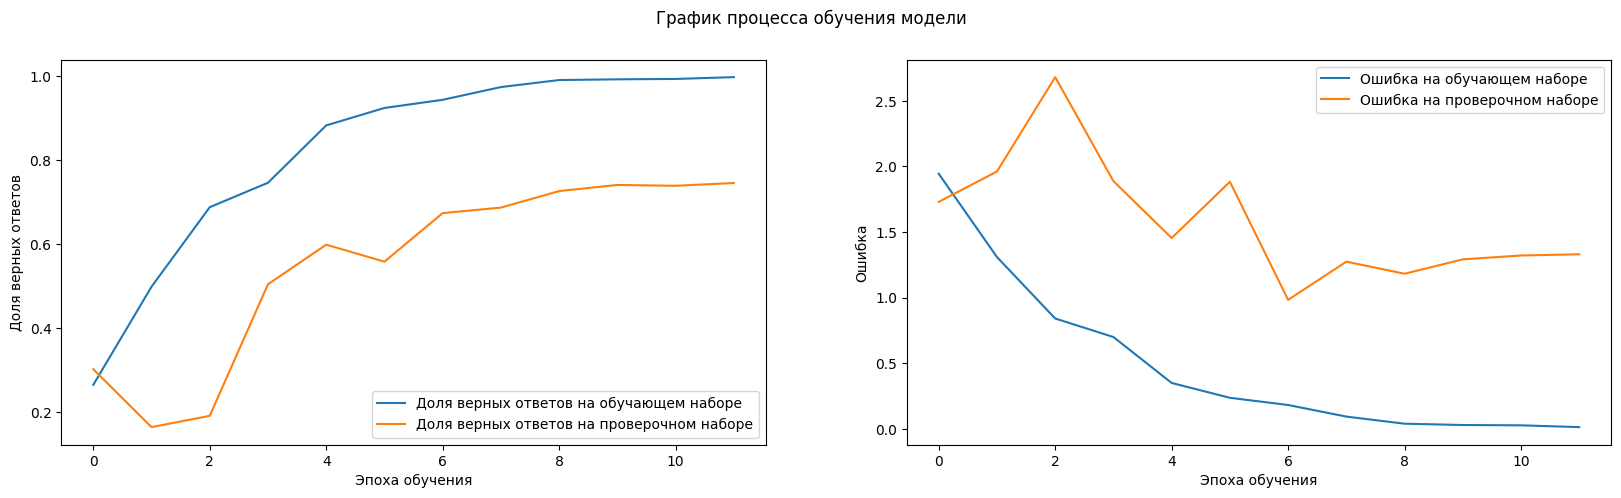

189/189 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step


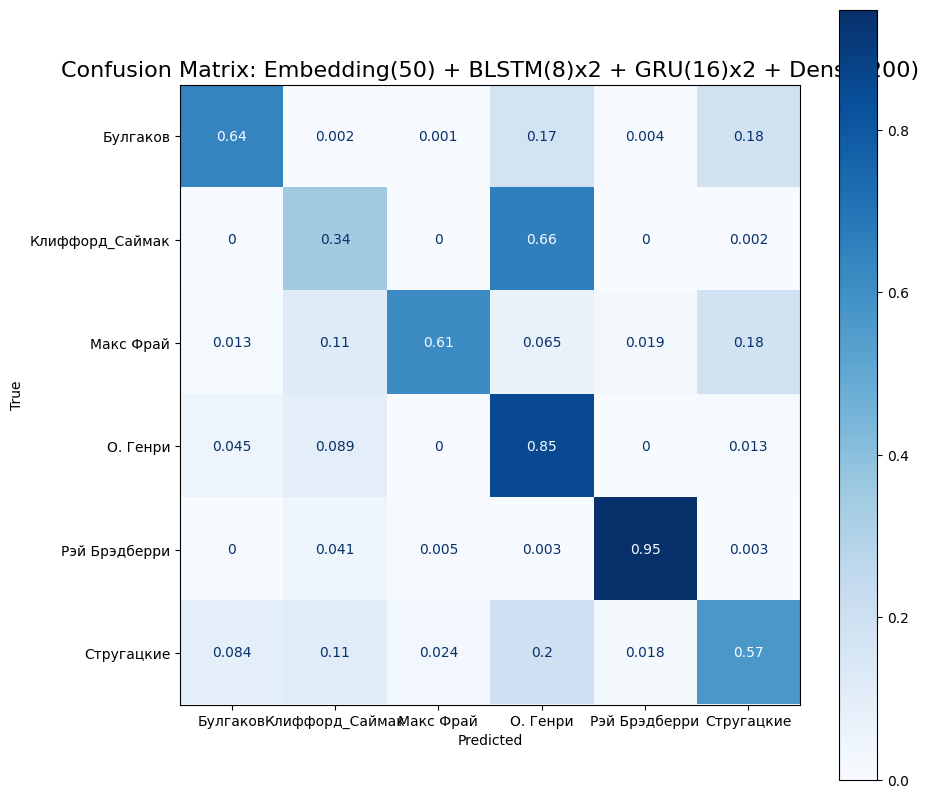

--------------------------------------------------------------------------------
Accuracy: 0.6736
Булгаков             → Булгаков             | OK
Клиффорд_Саймак      → О. Генри             | ERROR
Макс Фрай            → Макс Фрай            | OK
О. Генри             → О. Генри             | OK
Рэй Брэдберри        → Рэй Брэдберри        | OK
Стругацкие           → Стругацкие           | OK

Mean class accuracy: 0.6606


In [18]:
model_LSTM_2 = Sequential([
    Input(shape=(WIN_SIZE,)),   
    Embedding(VOCAB_SIZE, 50),
    SpatialDropout1D(0.4),
    BatchNormalization(),

    Bidirectional(LSTM(8, return_sequences=True)),
    Bidirectional(LSTM(8, return_sequences=True)),
    Dropout(0.3),
    BatchNormalization(),

    GRU(16, return_sequences=True, reset_after=True),
    GRU(16, reset_after=True),
    Dropout(0.3),
    BatchNormalization(),

    Dense(200, activation='relu'),
    Dropout(0.3),
    BatchNormalization(),
    Dense(CLASS_COUNT, activation='softmax')
]
)




compile_train_eval_model(model_LSTM_2,
                         x_train, y_train,
                         x_test, y_test,
                         epochs=EPOCHS,
                         batch_size=BATCH_SIZE,
                         class_labels=CLASS_LIST,
                         title='Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200)')

In [37]:
model_LSTM_2.save('model_LSTM_v_2.keras')

## Поменял длину отрезка текста 500 и шаг окна разбиения текста на 20, при этом оставил `VOCAB_SIZE=20000

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 500, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ (None, 500, 50)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 500, 50)        │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 500, 16)        │         3,776 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 500, 16)        │         1,600 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 500, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 500, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_10 (GRU)                    │ (None, 500, 16)        │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_11 (GRU)                    │ (None, 16)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 200)            │         3,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │         1,206 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,374 (3.87 MB)

 Trainable params: 1,013,810 (3.87 MB)

 Non-trainable params: 564 (2.20 KB)

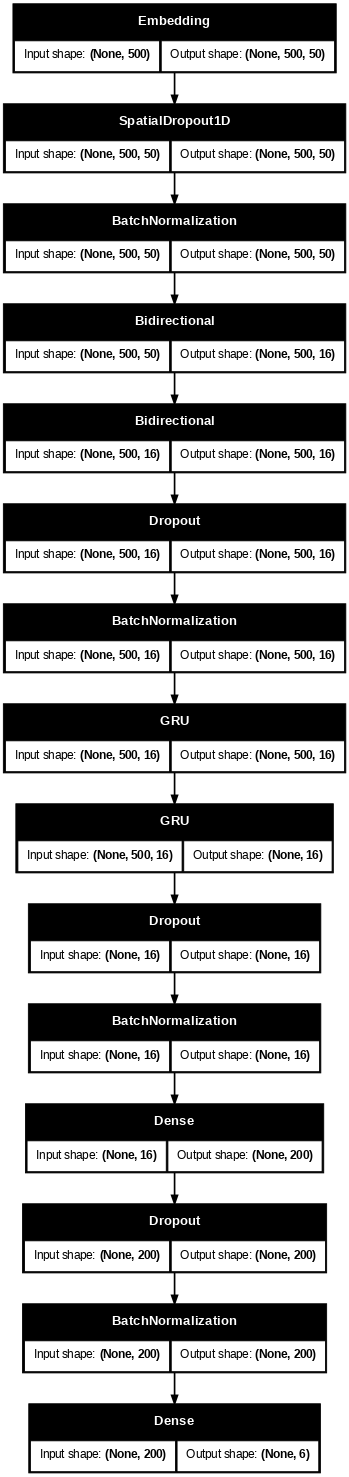

Epoch 1/50
618/618 ━━━━━━━━━━━━━━━━━━━━ 78s 116ms/step - accuracy: 0.5339 - loss: 1.2650 - val_accuracy: 0.5070 - val_loss: 1.3951
Epoch 2/50
618/618 ━━━━━━━━━━━━━━━━━━━━ 72s 116ms/step - accuracy: 0.8589 - loss: 0.3720 - val_accuracy: 0.6223 - val_loss: 1.3824
Epoch 3/50
618/618 ━━━━━━━━━━━━━━━━━━━━ 71s 115ms/step - accuracy: 0.9786 - loss: 0.0697 - val_accuracy: 0.6525 - val_loss: 1.6936
Epoch 4/50
618/618 ━━━━━━━━━━━━━━━━━━━━ 69s 112ms/step - accuracy: 0.9888 - loss: 0.0387 - val_accuracy: 0.5946 - val_loss: 2.1744
Epoch 5/50
618/618 ━━━━━━━━━━━━━━━━━━━━ 70s 113ms/step - accuracy: 0.9927 - loss: 0.0249 - val_accuracy: 0.6375 - val_loss: 2.1388
Epoch 6/50
618/618 ━━━━━━━━━━━━━━━━━━━━ 71s 115ms/step - accuracy: 0.9941 - loss: 0.0211 - val_accuracy: 0.6234 - val_loss: 2.5117
Epoch 7/50
618/618 ━━━━━━━━━━━━━━━━━━━━ 73s 118ms/step - accuracy: 0.9957 - loss: 0.0162 - val_accuracy: 0.6548 - val_loss: 2.3641


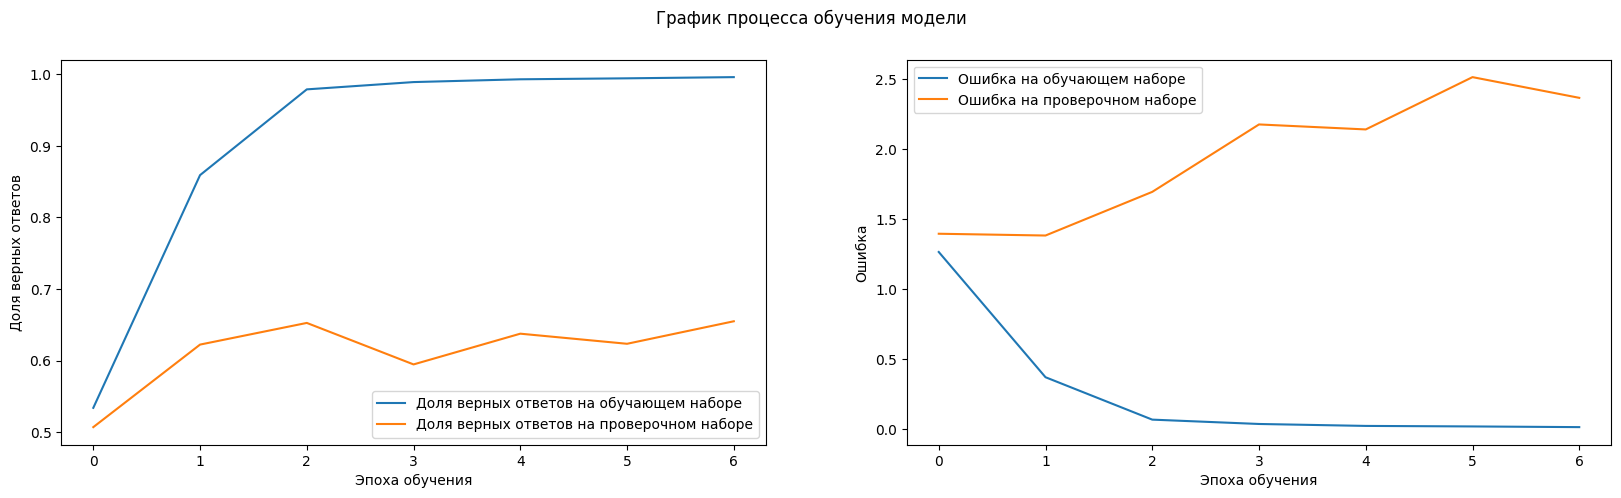

891/891 ━━━━━━━━━━━━━━━━━━━━ 35s 39ms/step


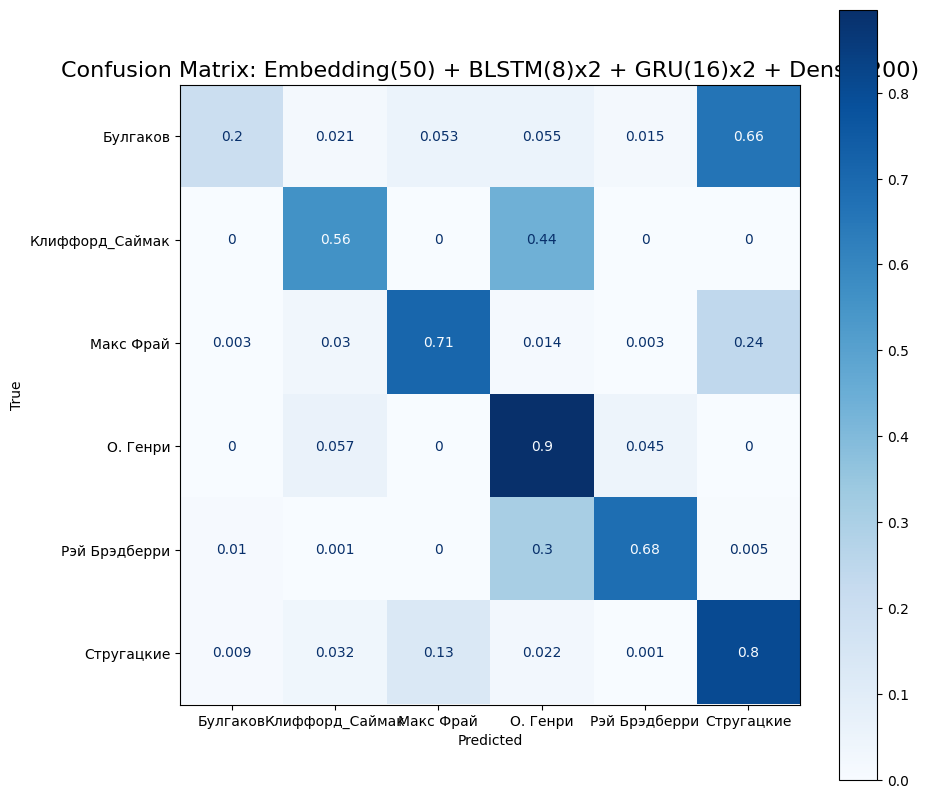

--------------------------------------------------------------------------------
Accuracy: 0.6223
Булгаков             → Стругацкие           | ERROR
Клиффорд_Саймак      → Клиффорд_Саймак      | OK
Макс Фрай            → Макс Фрай            | OK
О. Генри             → О. Генри             | OK
Рэй Брэдберри        → Рэй Брэдберри        | OK
Стругацкие           → Стругацкие           | OK

Mean class accuracy: 0.6415


In [35]:
model_LSTM_3 = Sequential([
    Input(shape=(WIN_SIZE,)),   
    Embedding(VOCAB_SIZE, 50),
    SpatialDropout1D(0.4),
    BatchNormalization(),

    Bidirectional(LSTM(8, return_sequences=True)),
    Bidirectional(LSTM(8, return_sequences=True)),
    Dropout(0.3),
    BatchNormalization(),

    GRU(16, return_sequences=True, reset_after=True),
    GRU(16, reset_after=True),
    Dropout(0.3),
    BatchNormalization(),

    Dense(200, activation='relu'),
    Dropout(0.3),
    BatchNormalization(),
    Dense(CLASS_COUNT, activation='softmax')
]
)




compile_train_eval_model(model_LSTM_3,
                         x_train, y_train,
                         x_test, y_test,
                         epochs=EPOCHS,
                         batch_size=BATCH_SIZE,
                         class_labels=CLASS_LIST,
                         title='Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200)')

In [38]:
model_LSTM_3.save('model_LSTM_v_3.keras')